# Statistical Analysis

У цьому ноутбуці виконується статистичний аналіз датасету US Accidents для виявлення закономірностей, взаємозв’язків між змінними та основних статистичних характеристик даних.

Основна увага приділяється descriptive statistics, correlation analysis, distribution analysis та дослідженню аномальних значень.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv(
    '/Users/veronika/Documents/US_Accidents_Project/data/processed/cleaned_us_accidents.csv'
)

## 1. Descriptive Statistics

У цьому блоці аналізуються основні статистичні характеристики числових змінних датасету для кращого розуміння структури даних та їх варіативності.

In [6]:
# вибір числових змінних для аналізу

numeric_columns = [
    'Severity',
    'Temperature(C)',
    'Visibility(km)',
    'Wind_Speed(kmh)',
    'Distance(km)'
]

df[numeric_columns].describe()

,Severity,Temperature(C),Visibility(km),Wind_Speed(kmh),Distance(km)
count,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000
mean,2.212451,16.480405,14.638714,12.261750,0.888751
std,0.487506,10.505465,3.935780,8.225662,2.562403
min,1.000000,-67.222222,0.000000,0.000000,0.000000
25%,2.000000,9.444444,16.093400,8.046700,0.000000
50%,2.000000,17.777778,16.093400,11.265380,0.048280
75%,2.000000,24.444444,16.093400,16.093400,0.745124
max,4.000000,60.000000,72.420300,271.978460,97.921902


In [9]:
df[numeric_columns].agg([
    'mean',
    'median',
    'std',
    'min',
    'max',
    'skew'
]).T

,mean,median,std,min,max,skew
Severity,2.212451,2.000000,0.487506,1.000000,4.000000,1.820735
Temperature(C),16.480405,17.777778,10.505465,-67.222222,60.000000,-0.506850
Visibility(km),14.638714,16.093400,3.935780,0.000000,72.420300,-1.039961
Wind_Speed(kmh),12.261750,11.265380,8.225662,0.000000,271.978460,1.175581
Distance(km),0.888751,0.048280,2.562403,0.000000,97.921902,9.691441


Висновок

Описова статистика показуює, що більшість аварій мають тяжкість рівня 2. Змінні distance та wind speed мають сильну правосторонню асиметрію, що свідчить про наявність екстримальних значень та потенційних викидів. Видимість має негативну асиметрію, оскільки більшість аварій трапляються за відносно високої видимості. Також у даних присутні дуже низькі та дуже високі температурні значення, що може бути пов’язано з екстремальними погодними умовами.

## 2. Distribution Analysis

У цьому блоці досліджуються розподіли числових змінних для виявлення асиметрії, концентрації значень та потенційних викидів.

In [11]:
# список змінних для distribution analysis

distribution_columns = [
    'Temperature(C)',
    'Visibility(km)',
    'Wind_Speed(kmh)',
    'Distance(km)'
]

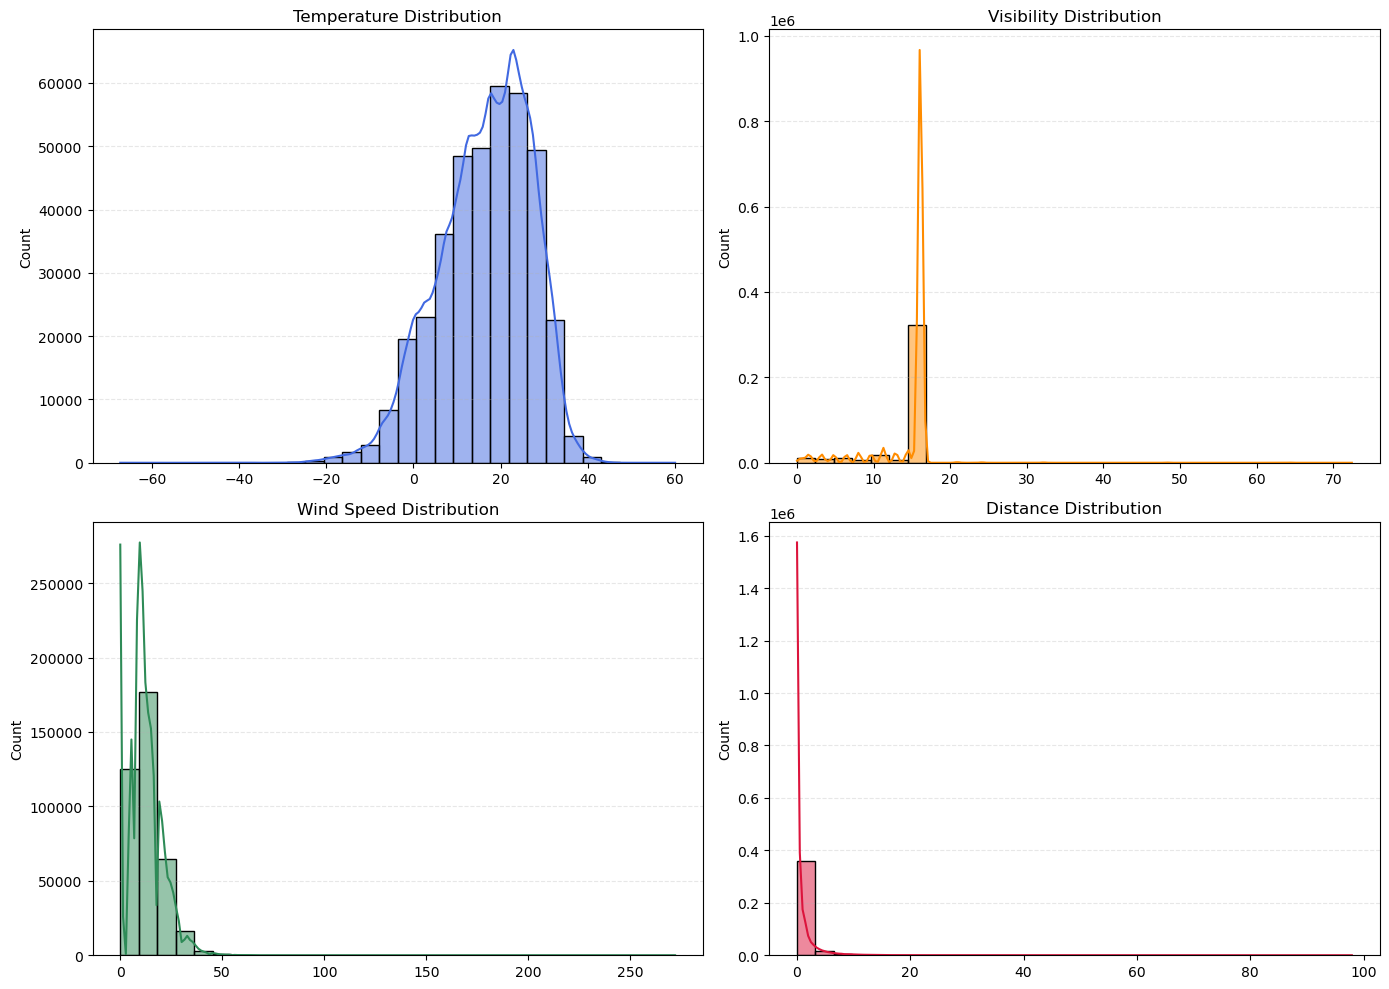

In [14]:
# Distribution dashboard

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

# Temperature distribution
sns.histplot(
    data=df,
    x='Temperature(C)',
    bins=30,
    kde=True,
    color='royalblue',
    ax=axes[0, 0]
)

axes[0, 0].set_title('Temperature Distribution')


# Visibility distribution
sns.histplot(
    data=df,
    x='Visibility(km)',
    bins=30,
    kde=True,
    color='darkorange',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Visibility Distribution')


# Wind speed distribution
sns.histplot(
    data=df,
    x='Wind_Speed(kmh)',
    bins=30,
    kde=True,
    color='seagreen',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Wind Speed Distribution')


# Distance distribution
sns.histplot(
    data=df,
    x='Distance(km)',
    bins=30,
    kde=True,
    color='crimson',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Distance Distribution')

for ax in axes.flat:

    ax.set_xlabel('')
    ax.set_ylabel('Count')

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

plt.tight_layout()
plt.show()

Висновок

Аналіз розподілу показує, що різні змінні мають суттєво відмінні типи розподілів. Температура має відносно наближений до нормального розподіл, тоді як швидкість вітру та відстань демонструють сильну правосторонню асиметрію через наявність екстримальних значень. 

## 3. Outlier Analysis

У цьому блоці досліджуються аномальні значення (outliers) у числових змінних датасету для виявлення екстремальних випадків та оцінки їх впливу на розподіли даних.

In [15]:
# змінні для outlier analysis

outlier_columns = [
    'Visibility(km)',
    'Wind_Speed(kmh)',
    'Distance(km)'
]

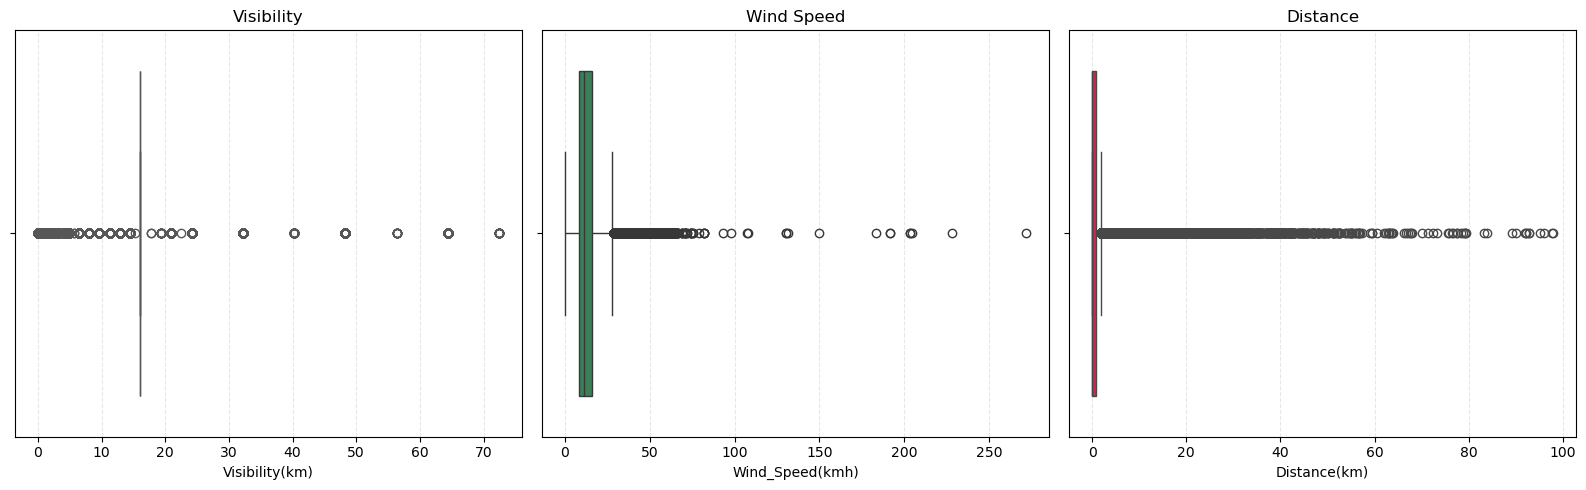

In [17]:
# Boxplot dashboard

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

# Visibility
sns.boxplot(
    data=df,
    x='Visibility(km)',
    color='royalblue',
    ax=axes[0]
)

axes[0].set_title('Visibility')


# Wind speed
sns.boxplot(
    data=df,
    x='Wind_Speed(kmh)',
    color='seagreen',
    ax=axes[1]
)

axes[1].set_title('Wind Speed')


# Distance
sns.boxplot(
    data=df,
    x='Distance(km)',
    color='crimson',
    ax=axes[2]
)

axes[2].set_title('Distance')


# Загальне оформлення

for ax in axes.flat:

    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [18]:
# розрахунок IQR outliers

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f'\n{column}')
    print(f'Outliers count: {len(outliers)}')


Visibility(km)
Outliers count: 73567

Wind_Speed(kmh)
Outliers count: 14362

Distance(km)
Outliers count: 48356


Висновок

Outlier analysis показує значну кількість аномальних значень у всіх досліджуваних змінних. Найбільше екстримальних значень спостерігається у видимості та дистанції, що свідчить про наявність нетипових дорожніх або погодних ситуацій. Швидкість вітру також містить екстремальні значення, хоча їх кількість є меншою порівняно з іншими змінними.

## 4. Correlation Analysis

У цьому блоці аналізуються взаємозв’язки між числовими змінними датасету для виявлення potential dependencies та сили кореляції між факторами.

In [19]:
# вибір числових змінних для correlation analysis

correlation_columns = [
    'Severity',
    'Temperature(C)',
    'Visibility(km)',
    'Wind_Speed(kmh)',
    'Distance(km)'
]

In [20]:
# сorrelation matrix

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

correlation_matrix

,Severity,Temperature(C),Visibility(km),Wind_Speed(kmh),Distance(km)
Severity,1.000000,-0.023679,-0.006965,0.038577,0.038733
Temperature(C),-0.023679,1.000000,0.232882,0.033006,-0.057880
Visibility(km),-0.006965,0.232882,1.000000,0.018199,-0.040400
Wind_Speed(kmh),0.038577,0.033006,0.018199,1.000000,0.013545
Distance(km),0.038733,-0.057880,-0.040400,0.013545,1.000000


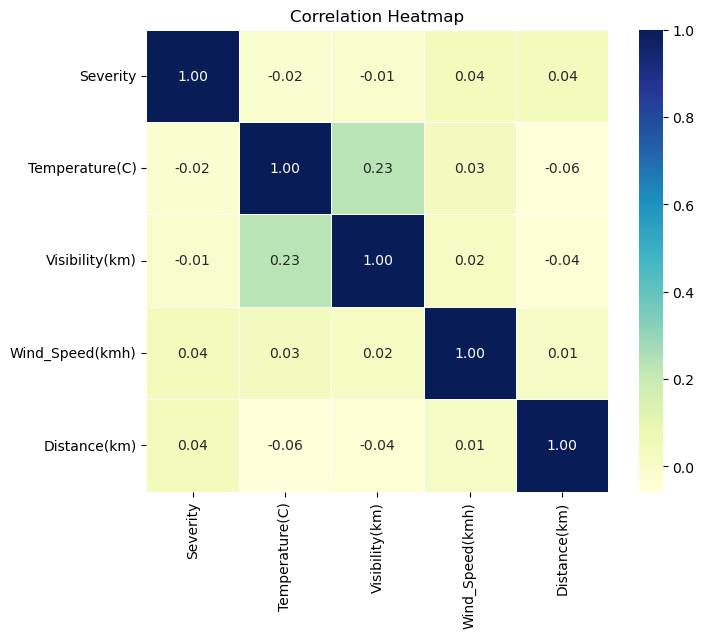

In [29]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap')

plt.show()

Висновок

Correlation analysis показав відсутність сильних лінійних залежностей між окремими числовими змінними. Це свідчить про те, що тяжкість ДТП формується під впливом комбінації кількох факторів, а не одного окремого показника.